In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "supplejade/rt-iot2022real-time-internet-of-things"
    )

print("Path to dataset files:", path)

Path to dataset files: C:\Users\tipqc\.cache\kagglehub\datasets\supplejade\rt-iot2022real-time-internet-of-things\versions\3


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('RT_IOT2022.csv')
data.head()

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [30]:
data.isnull().sum()

no                      0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64

In [31]:
data.columns

Index(['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration',
       'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count',
       'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count',
       'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count',
       'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count',
       'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
       'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min',
       'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',
       'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_payload.max', 'flow_pkts_payload.tot',
  

In [32]:
data.dtypes

no                        int64
id.orig_p                 int64
id.resp_p                 int64
proto                       str
service                     str
                         ...   
idle.std                float64
fwd_init_window_size      int64
bwd_init_window_size      int64
fwd_last_window_size      int64
Attack_type                 str
Length: 85, dtype: object

In [3]:
# Drop unnecessary columns
not_needed = ['id.orig_p', 'id.resp_p']
data.drop(columns=not_needed, errors='ignore')

,no,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,2005,tcp,-,0.000006,1,1,0,0,167772.160000,167772.160000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,2006,tcp,-,0.000007,1,1,0,0,144631.172414,144631.172414,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,2007,tcp,-,0.000006,1,1,0,0,167772.160000,167772.160000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,2008,tcp,-,0.000006,1,1,0,0,167772.160000,167772.160000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


Text(0.5, 0, 'Attacks')

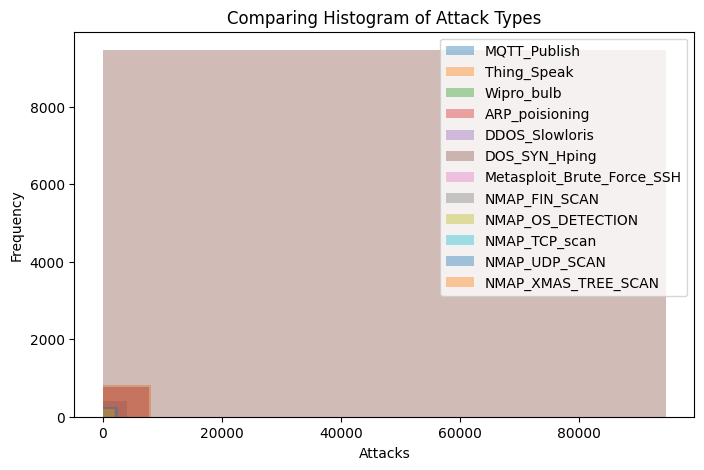

In [51]:
fig, axes = plt.subplots(figsize=(8, 5))
for attacks in data.Attack_type.unique():
    datas = data.query(f'Attack_type == "{attacks}"').no
    datas.plot(
      kind='hist', ax=axes, alpha=0.4,
      label=attacks, legend=True,
      title='Comparing Histogram of Attack Types'
      )
plt.xlabel('Attacks')


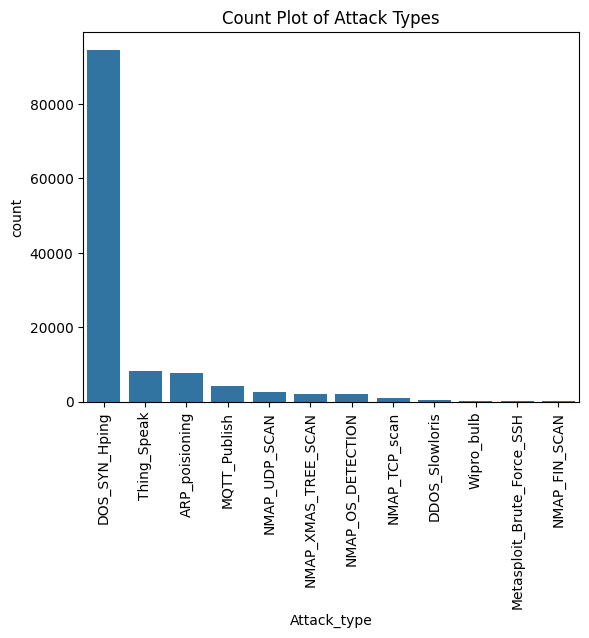

In [52]:
sns.countplot(data=data,x=data['Attack_type'],order=data['Attack_type'].value_counts().index)
plt.title('Count Plot of Attack Types')
plt.xticks(rotation=90)
plt.show()

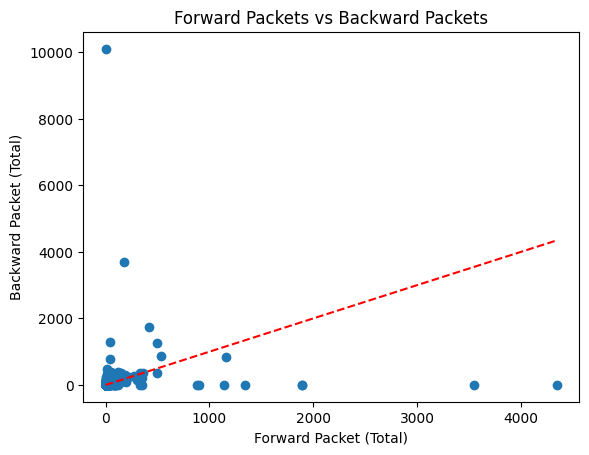

In [42]:
plt.scatter(data['fwd_data_pkts_tot'], data['bwd_data_pkts_tot'])
plt.title('Forward Packets vs Backward Packets')
plt.xlabel('Forward Packet (Total)')
plt.ylabel('Backward Packet (Total)')
plt.plot([0, data['fwd_pkts_tot'].max()], [0, data['fwd_pkts_tot'].max()], color='r', linestyle='--')
plt.show()

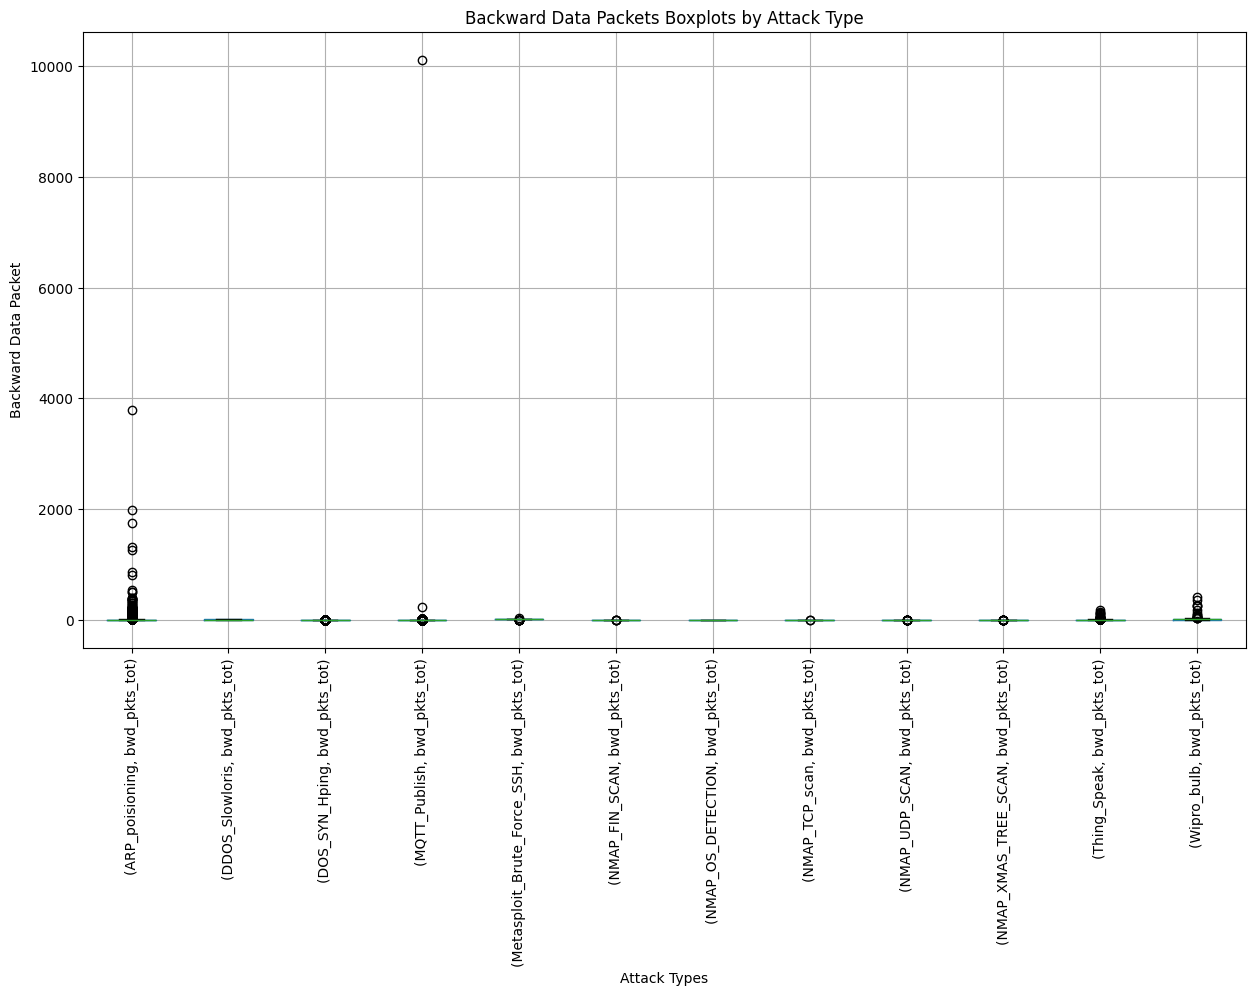

In [50]:
data[['bwd_pkts_tot', 'Attack_type']].groupby('Attack_type').boxplot(
figsize=(15, 8), subplots=False
)
plt.title('Backward Data Packets Boxplots by Attack Type')
plt.ylabel('Backward Data Packet') 
plt.xlabel('Attack Types')
plt.xticks(rotation=90)
plt.show()

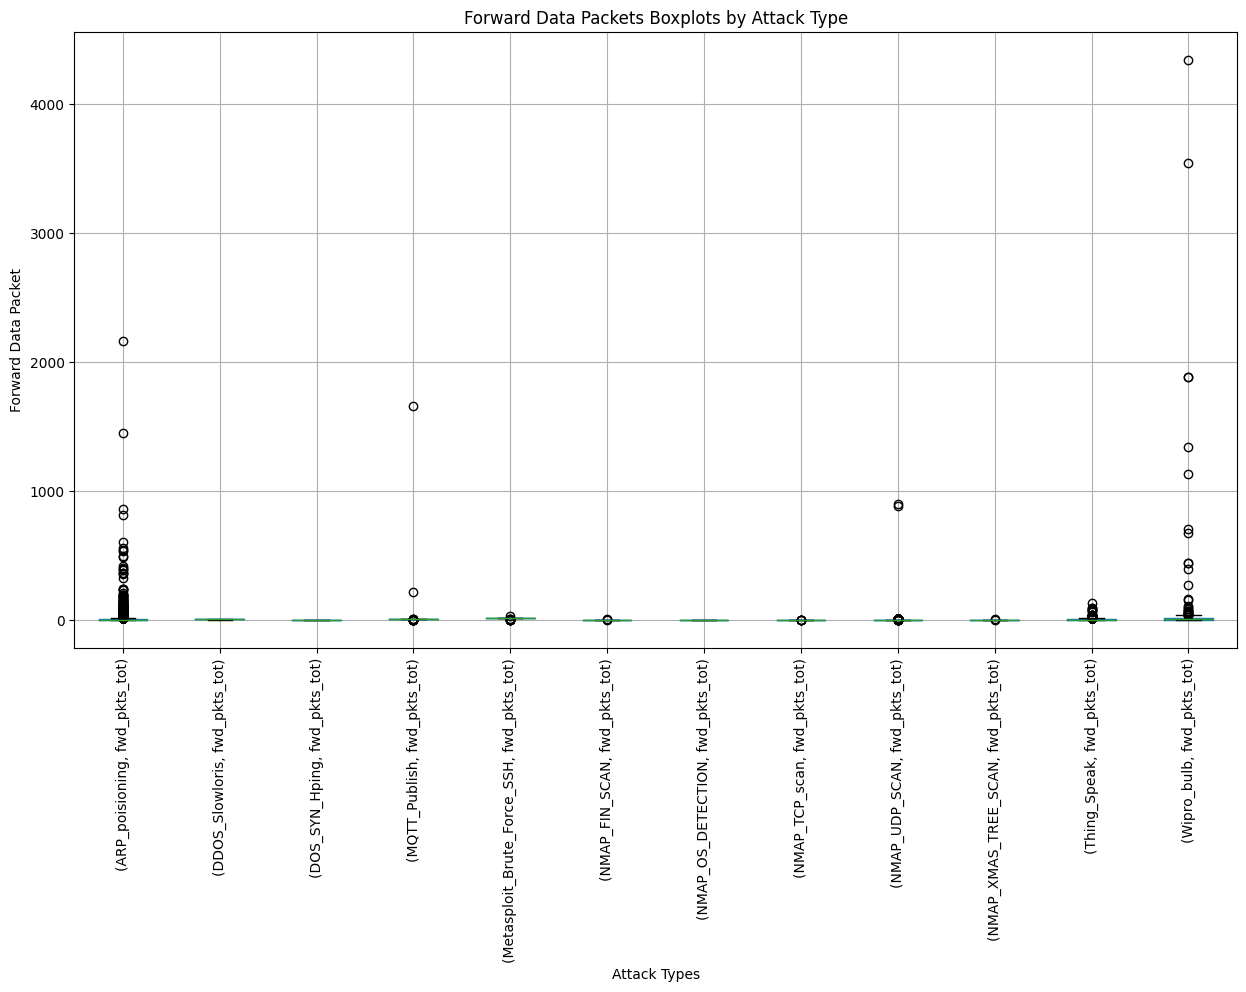

In [54]:
data[['fwd_pkts_tot', 'Attack_type']].groupby('Attack_type').boxplot(
figsize=(15, 8), subplots=False
)
plt.title('Forward Data Packets Boxplots by Attack Type')
plt.ylabel('Forward Data Packet') 
plt.xlabel('Attack Types')
plt.xticks(rotation=90)
plt.show()

Text(0.5, 0, 'Attack Type')

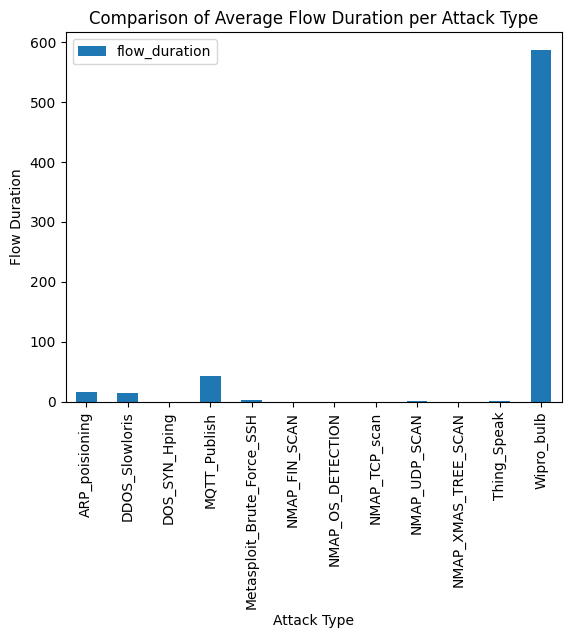

In [5]:
flow = data[['flow_duration', 'Attack_type']].groupby('Attack_type').mean()
flow.plot(kind='bar')
plt.ylabel('Flow Duration')
plt.title('Comparison of Average Flow Duration per Attack Type')
plt.xlabel('Attack Type')